In [ ]:
import torch
torch.cuda.is_available()


True

In [ ]:
!pip install kaggle
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install tensorflow keras


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"devaranavyasree","key":"450c2ef84b1214138e10fcadc2ae795d"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip


Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import zipfile

with zipfile.ZipFile('fer2013.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped successfully!")


Unzipped successfully!


In [ ]:
import os
os.listdir()


['.config', 'kaggle.json', 'fer2013.zip', 'train', 'test', 'sample_data']

In [ ]:
import zipfile

with zipfile.ZipFile('fer2013.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped successfully!")


Unzipped successfully!


In [ ]:
import os
os.listdir()


['.config', 'kaggle.json', 'fer2013.zip', 'train', 'test', 'sample_data']

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
img_size = 48
batch_size = 32


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


===== FER DATASET SUMMARY =====
Train samples: 28709
Test samples: 7178
Number of classes: 7
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

===== TRAIN CLASS DISTRIBUTION =====
angry       3995
disgust      436
fear        4097
happy       7215
neutral     4965
sad         4830
surprise    3171
Name: count, dtype: int64

===== TEST CLASS DISTRIBUTION =====
angry        958
disgust      111
fear        1024
happy       1774
neutral     1233
sad         1247
surprise     831
Name: count, dtype: int64


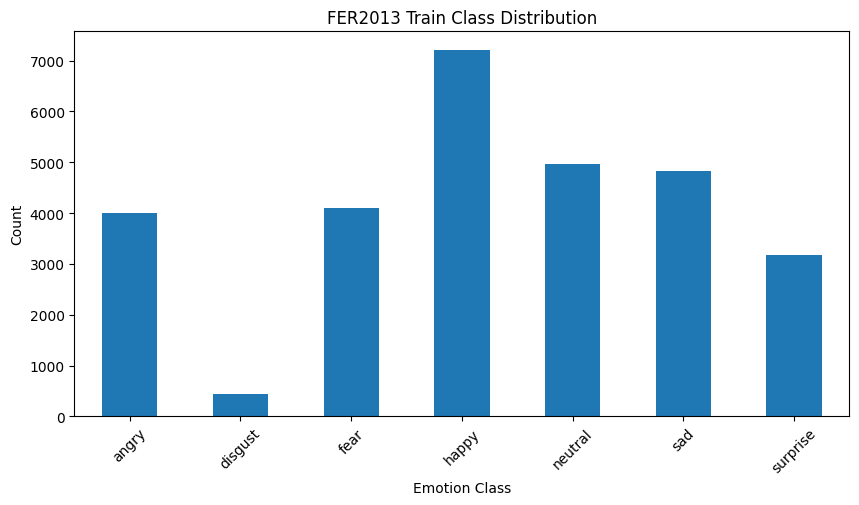


===== RANDOM TRAIN IMAGES =====


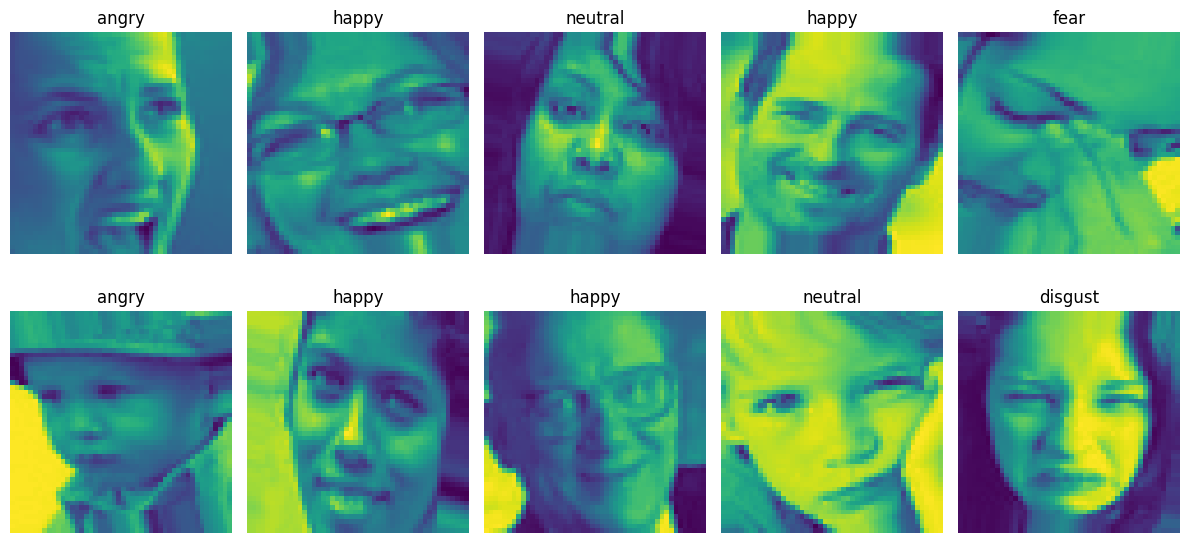


===== CLASS WEIGHTS (for training) =====
{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [ ]:
# ==============================
# Milestone 1 Completion (FER2013 Analysis)
# Paste AFTER train_generator and test_generator are created
# ==============================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1) Dataset summary
print("===== FER DATASET SUMMARY =====")
print("Train samples:", train_generator.samples)
print("Test samples:", test_generator.samples)
print("Number of classes:", train_generator.num_classes)
print("Class indices:", train_generator.class_indices)

# 2) Count samples per class
train_counts = pd.Series(train_generator.classes).value_counts().sort_index()
test_counts = pd.Series(test_generator.classes).value_counts().sort_index()

# Convert numeric labels to class names
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
train_counts.index = train_counts.index.map(idx_to_class)
test_counts.index = test_counts.index.map(idx_to_class)

print("\n===== TRAIN CLASS DISTRIBUTION =====")
print(train_counts)

print("\n===== TEST CLASS DISTRIBUTION =====")
print(test_counts)

# 3) Plot distribution
plt.figure(figsize=(10,5))
train_counts.plot(kind="bar")
plt.title("FER2013 Train Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 4) Visualize sample images
print("\n===== RANDOM TRAIN IMAGES =====")
images, labels = next(train_generator)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(idx_to_class[label_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 5) OPTIONAL: Class weights for imbalance (good practice)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print("\n===== CLASS WEIGHTS (for training) =====")
print(class_weights_dict)


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
print("Emotion Classes:", train_generator.class_indices)


Emotion Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
!kaggle datasets download -d tadepalli/lastfm-dataset


403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/tadepalli/lastfm-dataset


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"devaranavyasree","key":"450c2ef84b1214138e10fcadc2ae795d"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [26]:
!unzip "archive (1).zip"


Archive:  archive (1).zip
  inflating: MP3-Example/Blues/Blues-TRACOHF128F1498509.mp3  
  inflating: MP3-Example/Blues/Blues-TRADWSG128F4259317.mp3  
  inflating: MP3-Example/Blues/Blues-TRAELUY128F93147BA.mp3  
  inflating: MP3-Example/Blues/Blues-TRAHVWB128F9308FB0.mp3  
  inflating: MP3-Example/Blues/Blues-TRAJGIO128F92E84BC.mp3  
  inflating: MP3-Example/Blues/Blues-TRAOPNA128F427E83F.mp3  
  inflating: MP3-Example/Blues/Blues-TRAQGFP128E078FAB6.mp3  
  inflating: MP3-Example/Blues/Blues-TRARJEK128F930B3AA.mp3  
  inflating: MP3-Example/Blues/Blues-TRATLTV128F92FC979.mp3  
  inflating: MP3-Example/Blues/Blues-TRAUJPR128F92CA3AF.mp3  
  inflating: MP3-Example/Blues/Blues-TRAUYOD128F42647FE.mp3  
  inflating: MP3-Example/Blues/Blues-TRAYHQV128F4266D63.mp3  
  inflating: MP3-Example/Blues/Blues-TRBVOHY128F92E6A11.mp3  
  inflating: MP3-Example/Blues/Blues-TRCPUIL128F931ACAF.mp3  
  inflating: MP3-Example/Blues/Blues-TRCQEDW128E078F467.mp3  
  inflating: MP3-Example/Blues/Blues-TRCQIRC

In [27]:
import pandas as pd

# Load music metadata
music_df = pd.read_csv("Music Info.csv")

# Load user listening history
history_df = pd.read_csv("User Listening History.csv")

print("Music Info Shape:", music_df.shape)
print("Listening History Shape:", history_df.shape)

music_df.head()



Music Info Shape: (50683, 21)
Listening History Shape: (9711301, 3)


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


===== MUSIC DATASET SUMMARY =====
Shape: (50683, 21)

Columns:
Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

After cleaning:
Shape: (22348, 21)

===== MISSING VALUES REPORT =====
tags                   432
name                     0
artist                   0
spotify_preview_url      0
track_id                 0
spotify_id               0
genre                    0
year                     0
duration_ms              0
danceability             0
energy                   0
key                      0
loudness                 0
mode                     0
speechiness              0
dtype: int64

===== TOP 15 GENRES =====
genre
rock          9965
electronic    3710
metal         2516
pop           1145
rap            821
jazz    

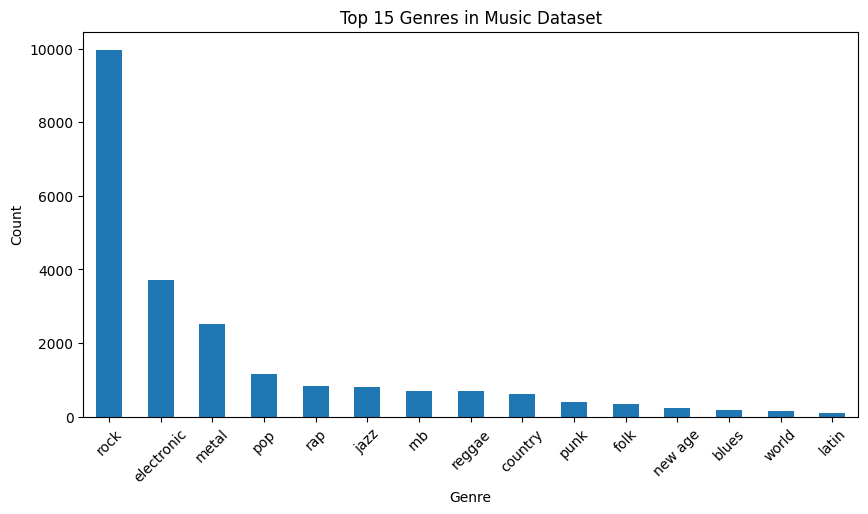


===== FINAL MUSIC DATASET READY =====
Shape: (7915, 2)
                   artist genre
2                 Nirvana   rnb
4               Radiohead   rnb
8                Coldplay  rock
10  Red Hot Chili Peppers   pop
12               Gorillaz   rnb


In [28]:
# ==============================
# Milestone 1 Completion (Music Dataset Cleaning + Feature Prep)
# Paste AFTER music_df is loaded
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("===== MUSIC DATASET SUMMARY =====")
print("Shape:", music_df.shape)
print("\nColumns:")
print(music_df.columns)

# 1) Basic cleaning
music_df = music_df.drop_duplicates()

# If genre column exists, clean it
if "genre" in music_df.columns:
    music_df["genre"] = music_df["genre"].astype(str).str.lower().str.strip()

# Remove empty genres if present
if "genre" in music_df.columns:
    music_df = music_df[music_df["genre"].notna()]
    music_df = music_df[music_df["genre"] != "nan"]
    music_df = music_df[music_df["genre"] != ""]
    music_df = music_df[music_df["genre"] != "none"]

print("\nAfter cleaning:")
print("Shape:", music_df.shape)

# 2) Missing values report
print("\n===== MISSING VALUES REPORT =====")
print(music_df.isnull().sum().sort_values(ascending=False).head(15))

# 3) Genre distribution (Top 15)
if "genre" in music_df.columns:
    print("\n===== TOP 15 GENRES =====")
    top_genres = music_df["genre"].value_counts().head(15)
    print(top_genres)

    plt.figure(figsize=(10,5))
    top_genres.plot(kind="bar")
    plt.title("Top 15 Genres in Music Dataset")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# 4) Create a final clean music table (for recommendation)
important_cols = []

# Try to keep the best columns if they exist
for col in ["track_name", "artist", "title", "song", "track", "genre"]:
    if col in music_df.columns:
        important_cols.append(col)

final_music_df = music_df[important_cols].copy() if important_cols else music_df.copy()

# Rename common variants to standard names
rename_map = {}
if "title" in final_music_df.columns:
    rename_map["title"] = "track_name"
if "song" in final_music_df.columns:
    rename_map["song"] = "track_name"
if "track" in final_music_df.columns:
    rename_map["track"] = "track_name"

final_music_df = final_music_df.rename(columns=rename_map)

# Drop duplicates again
final_music_df = final_music_df.drop_duplicates()

print("\n===== FINAL MUSIC DATASET READY =====")
print("Shape:", final_music_df.shape)
print(final_music_df.head())


In [29]:
print(music_df.columns)
print(history_df.columns)


Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')
Index(['track_id', 'user_id', 'playcount'], dtype='object')


In [30]:
# Remove duplicates
music_df = music_df.drop_duplicates()

# Remove missing values
music_df = music_df.dropna()

print("After cleaning:", music_df.shape)


After cleaning: (21916, 21)


In [31]:
music_df.head()


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",rnb,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",rnb,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4
8,TRMZXEW128F9341FD5,The Scientist,Coldplay,https://p.scdn.co/mp3-preview/95cb9df1b056d759...,0GSSsT9szp0rJkBrYkzy6s,"rock, alternative, indie, pop, alternative_roc...",rock,2007,311014,0.566,...,5,-7.826,1,0.0242,0.715000,0.000014,0.1200,0.173,146.365,4
10,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",pop,2003,265506,0.554,...,4,-8.046,1,0.0457,0.016800,0.000534,0.1360,0.513,84.275,4
12,TRYEZGE128F92D04C8,Feel Good Inc.,Gorillaz,https://p.scdn.co/mp3-preview/7388c425022ced92...,09xrHi86kLkEIzDLZiHNnv,"rock, electronic, alternative, indie, pop, alt...",rnb,2010,223106,0.809,...,6,-7.776,1,0.1360,0.033700,0.001410,0.8260,0.832,138.556,4


In [32]:
print(music_df.columns)


Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')


In [33]:
music_df.head()


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",rnb,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",rnb,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4
8,TRMZXEW128F9341FD5,The Scientist,Coldplay,https://p.scdn.co/mp3-preview/95cb9df1b056d759...,0GSSsT9szp0rJkBrYkzy6s,"rock, alternative, indie, pop, alternative_roc...",rock,2007,311014,0.566,...,5,-7.826,1,0.0242,0.715000,0.000014,0.1200,0.173,146.365,4
10,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",pop,2003,265506,0.554,...,4,-8.046,1,0.0457,0.016800,0.000534,0.1360,0.513,84.275,4
12,TRYEZGE128F92D04C8,Feel Good Inc.,Gorillaz,https://p.scdn.co/mp3-preview/7388c425022ced92...,09xrHi86kLkEIzDLZiHNnv,"rock, electronic, alternative, indie, pop, alt...",rnb,2010,223106,0.809,...,6,-7.776,1,0.1360,0.033700,0.001410,0.8260,0.832,138.556,4


In [34]:
['song', 'artist', 'genre']


['song', 'artist', 'genre']

In [35]:
def recommend_by_genre(genre_name, n=10):
    genre_name = str(genre_name).lower().strip()

    # Clean genre column safely
    music_df["genre_clean"] = music_df["genre"].astype(str).str.lower().str.strip()

    # Use contains instead of ==
    filtered = music_df[music_df["genre_clean"].str.contains(genre_name, na=False)]

    if filtered.empty:
        return f"No songs found for genre containing: '{genre_name}'"

    return filtered.head(n)


In [36]:
recommend_by_genre("pop")


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_clean
10,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",pop,2003,265506,0.554,...,-8.046,1,0.0457,0.016800,0.000534,0.1360,0.513,84.275,4,pop
39,TRAOMFT128F42A7684,Losing My Religion,R.E.M.,https://p.scdn.co/mp3-preview/7e795b53f58d926a...,04pRvt8HcPmmP6EeZoYMxa,"rock, alternative, indie, pop, alternative_roc...",pop,2014,288160,0.668,...,-10.753,0,0.0277,0.011500,0.000259,0.3370,0.629,126.978,4,pop
93,TRRVVTK128F422BB5D,Don't Stop Me Now,Queen,https://p.scdn.co/mp3-preview/6042b8adbf1102b2...,0ch4H0B6RvfOvpI47YXyre,"rock, classic_rock, 80s, british, 70s",pop,1979,268173,0.450,...,-11.825,1,0.1940,0.050200,0.000241,0.6890,0.230,159.335,4,pop
94,TROCLWN128F92EB284,Fluorescent Adolescent,Arctic Monkeys,https://p.scdn.co/mp3-preview/cb8560b45aa0d402...,02Y78WneC8bUaKWouKl00v,"rock, alternative, indie, alternative_rock, in...",pop,2007,177534,0.647,...,-5.222,0,0.0291,0.001960,0.000030,0.1770,0.813,112.109,4,pop
312,TRADJBK128F1453605,In Too Deep,Sum 41,https://p.scdn.co/mp3-preview/66eca3757c201239...,0GH52eIynfyKDPDGWHvRan,"rock, alternative, alternative_rock, punk, pun...",pop,2010,206493,0.569,...,-6.819,1,0.0593,0.000217,0.000000,0.0644,0.755,116.013,4,pop
404,TRILYBE128F428923B,Perfect Day,Lou Reed,https://p.scdn.co/mp3-preview/a48050121ba5ec0d...,003n4ftz70WFRbPyuBd9a3,"rock, classic_rock, singer_songwriter, soundtr...",pop,1972,224600,0.390,...,-15.740,1,0.0327,0.688000,0.000412,0.1020,0.106,147.270,3,pop
437,TRXFYTA128F429364C,Wild Horses,The Rolling Stones,https://p.scdn.co/mp3-preview/95f9ab1dad3bb25b...,1hsrmBpddP05q7XvJA8ehw,"rock, classic_rock, british, 70s, blues_rock",pop,2011,344386,0.443,...,-9.750,1,0.0267,0.666000,0.000785,0.0813,0.178,140.749,4,pop
489,TRCVUEM12903CB61A2,Ticket to Ride,The Beatles,https://p.scdn.co/mp3-preview/f136a4923ab251ca...,2gf83374sa2JqtrYxGYdPU,"rock, pop, classic_rock, british, 60s, oldies",pop,2008,193120,0.500,...,-18.803,0,0.0655,0.014900,0.000000,0.2350,0.570,123.460,4,pop
560,TRWIKBF128F92DD506,Goodbye My Lover,James Blunt,https://p.scdn.co/mp3-preview/f9126a8531cc8006...,0Iit3mwdeG3aIcK4kOviUo,"rock, alternative, indie, pop, singer_songwrit...",pop,2012,258373,0.412,...,-10.079,1,0.0546,0.950000,0.003880,0.0944,0.265,79.907,3,pop
580,TRDBHKC128F42A3A97,You Found Me,The Fray,https://p.scdn.co/mp3-preview/4d14eda64e96e13b...,0JBBvihPCdRiq1YPds4VYI,"rock, alternative, indie, pop, alternative_roc...",pop,2003,243733,0.336,...,-5.411,0,0.0420,0.019100,0.000000,0.1340,0.395,152.074,4,pop


In [44]:
def recommend_by_emotion(emotion):
    genre = emotion_to_genre.get(emotion)
    return recommend_by_genre(genre)

recommend_by_emotion("happy")


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_clean
10,TRIODZU128E078F3E2,Under the Bridge,Red Hot Chili Peppers,https://p.scdn.co/mp3-preview/90e41778392f27b6...,06zh28PcYIFvNOAz5Wq2Xb,"rock, alternative, alternative_rock, 90s, funk",pop,2003,265506,0.554,...,-8.046,1,0.0457,0.016800,0.000534,0.1360,0.513,84.275,4,pop
39,TRAOMFT128F42A7684,Losing My Religion,R.E.M.,https://p.scdn.co/mp3-preview/7e795b53f58d926a...,04pRvt8HcPmmP6EeZoYMxa,"rock, alternative, indie, pop, alternative_roc...",pop,2014,288160,0.668,...,-10.753,0,0.0277,0.011500,0.000259,0.3370,0.629,126.978,4,pop
93,TRRVVTK128F422BB5D,Don't Stop Me Now,Queen,https://p.scdn.co/mp3-preview/6042b8adbf1102b2...,0ch4H0B6RvfOvpI47YXyre,"rock, classic_rock, 80s, british, 70s",pop,1979,268173,0.450,...,-11.825,1,0.1940,0.050200,0.000241,0.6890,0.230,159.335,4,pop
94,TROCLWN128F92EB284,Fluorescent Adolescent,Arctic Monkeys,https://p.scdn.co/mp3-preview/cb8560b45aa0d402...,02Y78WneC8bUaKWouKl00v,"rock, alternative, indie, alternative_rock, in...",pop,2007,177534,0.647,...,-5.222,0,0.0291,0.001960,0.000030,0.1770,0.813,112.109,4,pop
312,TRADJBK128F1453605,In Too Deep,Sum 41,https://p.scdn.co/mp3-preview/66eca3757c201239...,0GH52eIynfyKDPDGWHvRan,"rock, alternative, alternative_rock, punk, pun...",pop,2010,206493,0.569,...,-6.819,1,0.0593,0.000217,0.000000,0.0644,0.755,116.013,4,pop
404,TRILYBE128F428923B,Perfect Day,Lou Reed,https://p.scdn.co/mp3-preview/a48050121ba5ec0d...,003n4ftz70WFRbPyuBd9a3,"rock, classic_rock, singer_songwriter, soundtr...",pop,1972,224600,0.390,...,-15.740,1,0.0327,0.688000,0.000412,0.1020,0.106,147.270,3,pop
437,TRXFYTA128F429364C,Wild Horses,The Rolling Stones,https://p.scdn.co/mp3-preview/95f9ab1dad3bb25b...,1hsrmBpddP05q7XvJA8ehw,"rock, classic_rock, british, 70s, blues_rock",pop,2011,344386,0.443,...,-9.750,1,0.0267,0.666000,0.000785,0.0813,0.178,140.749,4,pop
489,TRCVUEM12903CB61A2,Ticket to Ride,The Beatles,https://p.scdn.co/mp3-preview/f136a4923ab251ca...,2gf83374sa2JqtrYxGYdPU,"rock, pop, classic_rock, british, 60s, oldies",pop,2008,193120,0.500,...,-18.803,0,0.0655,0.014900,0.000000,0.2350,0.570,123.460,4,pop
560,TRWIKBF128F92DD506,Goodbye My Lover,James Blunt,https://p.scdn.co/mp3-preview/f9126a8531cc8006...,0Iit3mwdeG3aIcK4kOviUo,"rock, alternative, indie, pop, singer_songwrit...",pop,2012,258373,0.412,...,-10.079,1,0.0546,0.950000,0.003880,0.0944,0.265,79.907,3,pop
580,TRDBHKC128F42A3A97,You Found Me,The Fray,https://p.scdn.co/mp3-preview/4d14eda64e96e13b...,0JBBvihPCdRiq1YPds4VYI,"rock, alternative, indie, pop, alternative_roc...",pop,2003,243733,0.336,...,-5.411,0,0.0420,0.019100,0.000000,0.1340,0.395,152.074,4,pop


In [39]:
print(music_df.columns)


Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'genre_clean'],
      dtype='object')


In [40]:
print(music_df['genre'].unique())


['rnb' 'rock' 'pop' 'metal' 'electronic' 'jazz' 'punk' 'country' 'folk'
 'reggae' 'rap' 'blues' 'new age' 'latin' 'world']


In [41]:
emotion_to_genre = {
    "happy": "pop",
    "sad": "acoustic",
    "angry": "metal",
    "neutral": "classical",
    "surprise": "dance",
    "fear": "ambient",
    "disgust": "rock"
}


In [42]:
def recommend_by_emotion(emotion, n=10):
    emotion = emotion.lower().strip()
    genre = emotion_to_genre.get(emotion)

    if genre is None:
        return f"Emotion '{emotion}' not mapped."

    # Make genre matching case-insensitive
    music_df["genre_clean"] = music_df["genre"].astype(str).str.lower().str.strip()

    filtered = music_df[music_df["genre_clean"] == genre.lower().strip()]

    if filtered.empty:
        return f"No songs found for genre '{genre}'. Try another mapping."

    return filtered.sample(min(n, len(filtered)))


In [43]:
recommend_by_emotion("happy")


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre_clean
26980,TRXDSXC128F92F3147,Das Spiel,Annett Louisan,https://p.scdn.co/mp3-preview/2d1392a923c74c8f...,0fmxECAWK01XAAlrBgUkL5,"pop, female_vocalists, german",pop,2011,182800,0.652,...,-9.223,1,0.0316,0.7770,0.003450,0.1160,0.769,142.929,3,pop
41039,TREBSLJ128F425A56B,"Vi två, 17 år",Håkan Hellström,https://p.scdn.co/mp3-preview/081eafc92dee1fdd...,4NAo9ztGA8sm4Ac0T7hKgm,"indie, pop, swedish",pop,2007,236400,0.283,...,-5.992,1,0.0431,0.0377,0.000023,0.5170,0.215,81.190,4,pop
32883,TRHTQGT128F92DFC7A,Enter the Circus,Christina Aguilera,https://p.scdn.co/mp3-preview/43aa769e50969087...,0jIM6mfHgrSzvcBNBiS1ty,"pop, female_vocalists, rnb",pop,2006,102466,0.345,...,-5.400,0,0.2240,0.4430,0.000002,0.7320,0.125,107.939,4,pop
46801,TRTCSTF12903CE3859,We Won't Run,Sarah Blasko,https://p.scdn.co/mp3-preview/1410454d4d30cfec...,0IgxSXklwCn8VXj5XPBTnY,"indie, pop, female_vocalists",pop,2010,240533,0.709,...,-8.432,1,0.0618,0.4620,0.000083,0.1260,0.358,122.139,4,pop
17175,TRULZJB128F4291EC4,Do Somethin',Britney Spears,https://p.scdn.co/mp3-preview/a251c1140d074a20...,01ACsk2knUnsfWeZp63nqa,"pop, dance",pop,2004,204493,0.845,...,-3.262,1,0.0671,0.0278,0.000036,0.3700,0.962,129.943,4,pop
34728,TRCVABP12903CE8ACA,Obviously,McFly,https://p.scdn.co/mp3-preview/69771e6cea66b2a2...,0GzJn9eWv8782l7EeED5PX,"rock, pop, british, male_vocalists, love, brit...",pop,2004,198933,0.638,...,-2.491,1,0.0330,0.2000,0.000000,0.1160,0.738,130.649,4,pop
6092,TRCQZXN128F14A2417,We Belong Together,Mariah Carey,https://p.scdn.co/mp3-preview/dc2b7c6405c923fd...,0MtFUqaaEIqImt50RgfqZ4,"pop, female_vocalists, soul, rnb, love",pop,2005,201440,0.841,...,-7.917,1,0.0660,0.0270,0.000000,0.0910,0.765,139.974,4,pop
29907,TRPBSNS128F932EC0D,Bird of the Summer,A Fine Frenzy,https://p.scdn.co/mp3-preview/3b788e2087e4b140...,6683Ew0opY9AvL7FDkymxu,"indie, female_vocalists, folk, singer_songwrit...",pop,2009,198960,0.613,...,-7.654,1,0.0309,0.2570,0.000051,0.1360,0.420,120.105,4,pop
48527,TRTEMTL128EF357AA8,Ladies of the Canyon,Joni Mitchell,https://p.scdn.co/mp3-preview/234cb9750d5d339d...,1DyCB4sxfpp2ISZKvYTZvq,"folk, singer_songwriter",pop,2012,212933,0.580,...,-10.486,0,0.0251,0.8080,0.000000,0.0793,0.443,112.420,3,pop
36991,TROISRH128F1490FAE,Un Point C'Est Toi,Zazie,https://p.scdn.co/mp3-preview/cfdd2a700447b561...,1GcepV6gn6X9RvzhcPDZXk,french,pop,2002,210360,0.699,...,-6.153,0,0.0383,0.0412,0.000990,0.0649,0.841,110.974,4,pop


In [45]:
!pip install kaggle
!pip install tensorflow

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [55]:
!ls

'archive (1).zip'   MP3-Example       test
 fer2013.zip	   'Music Info.csv'   train
'kaggle (1).json'   sample_data      'User Listening History.csv'


In [56]:
!ls train

angry  disgust	fear  happy  neutral  sad  surprise


In [76]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [77]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [78]:
train_data = train_datagen.flow_from_directory(
    "train",
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    "test",
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [79]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

In [80]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,327 (1.74 MB)

 Trainable params: 455,879 (1.74 MB)

 Non-trainable params: 448 (1.75 KB)

In [91]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.5997 - loss: 1.0634 - val_accuracy: 0.6084 - val_loss: 1.0461
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.6011 - loss: 1.0485 - val_accuracy: 0.5974 - val_loss: 1.0744
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.6091 - loss: 1.0435 - val_accuracy: 0.6151 - val_loss: 1.0330
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.6016 - loss: 1.0535 - val_accuracy: 0.6071 - val_loss: 1.0456
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.6076 - loss: 1.0478 - val_accuracy: 0.5971 - val_loss: 1.0595
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.6098 - loss: 1.0465 - val_accuracy: 0.6115 - val_loss: 1.0270
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.6015 - loss: 1.0527 - val_accuracy: 0.5896 - val_loss: 1.0893
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.6041 - loss: 1.0418 - 

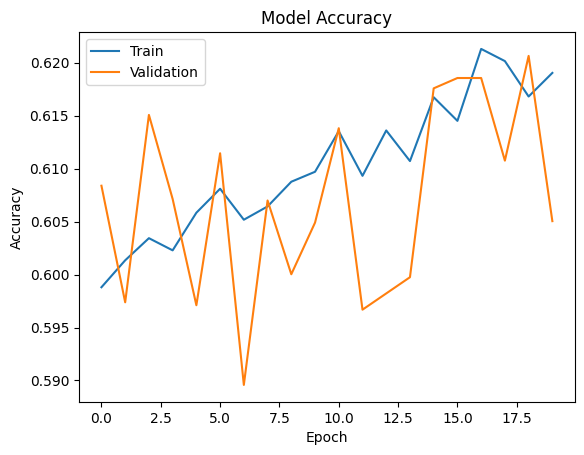

In [92]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

In [93]:
model.save("emotion_model.h5")

In [94]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.6190392971038818
Final Validation Accuracy: 0.6050431728363037
